# Cross-venue VPIN concordance


In [1]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'vpin_of'
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'

def jload(rel):
    p = OUT / rel
    return json.loads(p.read_text()) if p.is_file() else {}

def jlines(rel):
    p = OUT / rel
    if not p.is_file():
        return []
    return [json.loads(ln) for ln in p.read_text().splitlines() if ln.strip()]

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing* `{p}` — run `scripts/build_notebook_figs.py`'))

dec = jload('pass2/decisions_pass2.json') or jload('vpin_panel/decisions.json')
dec_promote = jload('vpin_panel/decisions_panel_promote.json')
rows = jlines('vpin_panel/rows.jsonl')
panel_ext = jload('pass2/panel_hl_db_extended.json')
ok_rows = panel_ext if isinstance(panel_ext, list) and panel_ext else [r for r in rows if r.get('ok')]
p2 = jload('pass2/pass2_summary.json')
print('pass2' if p2 else 'pass1', 'n_ok', dec.get('n_ok'), 'promote n_ok', dec_promote.get('n_ok'), 'counts', dec.get('decision_counts'))


pass2 n_ok 226 promote n_ok 139 counts {'Promote': 6, 'Hold': 5}


**HL↔DB scatter** — `out/desk_synthesis/figs/fig_xvenue_scatter.png`

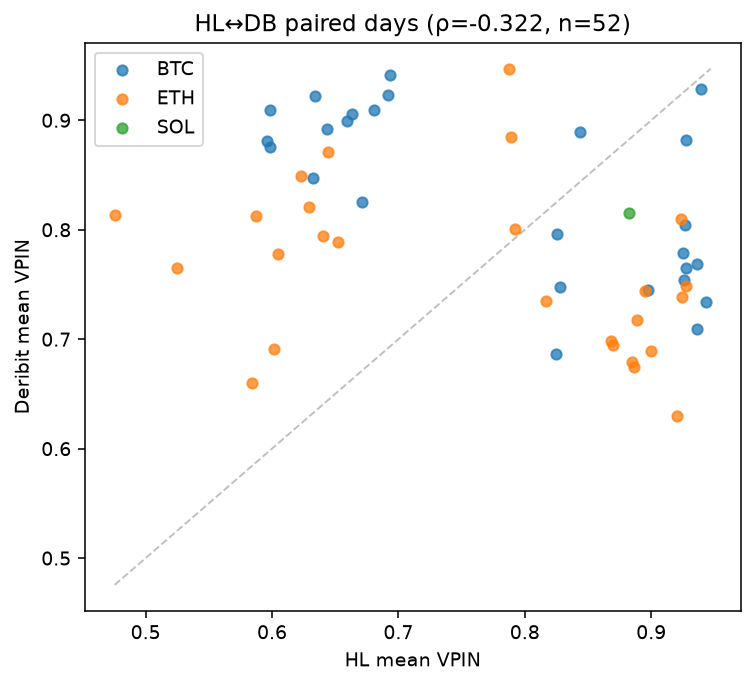

Gate frag.xvenue_vpin_concord: **Hold** — ρ=-0.32177921967045164 CI=[-0.5561982412703833,-0.05243105950653127] n=52.0

In [2]:
show_fig('fig_xvenue_scatter.png', 'HL↔DB scatter')
xv = (dec.get('falsifiers') or {}).get('xvenue_spearman', {})
display(Markdown(f"Gate frag.xvenue_vpin_concord: **Hold** — ρ={xv.get('rho')} CI=[{xv.get('lo')},{xv.get('hi')}] n={xv.get('n')}"))
